In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\THAHEER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\THAHEER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\THAHEER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
df = pd.read_csv("Data/clinical_trials_raw_patient2trial_conditions.csv")
print(df.shape)
df.head()

(60337, 16)


,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [9]:
df.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

print(df.shape)

(60337, 16)


In [12]:
df.dropna(inplace=True)

print(df.shape)

(10971, 16)


In [ ]:
def map_disease(condition):

    condition = str(condition).lower()

    if "breast" in condition or "cancer" in condition or "tumor" in condition:
        return "Cancer"

    elif "diabetes" in condition:
        return "Diabetes"

    elif "covid" in condition:
        return "COVID"

    elif "copd" in condition or "pulmonary" in condition:
        return "Respiratory"

    elif "arthritis" in condition:
        return "Arthritis"

    elif "sickle" in condition:
        return "Blood Disorder"

    elif "anxiety" in condition or "obsessive" in condition:
        return "Mental Health"

    else:
        return "Other"  

In [15]:
df["disease_category"] = df["conditions"].apply(map_disease)

In [16]:
df["disease_category"].value_counts()

disease_category
Diabetes          3330
Cancer            2264
Other             1578
COVID             1102
Respiratory        857
Arthritis          822
Mental Health      682
Blood Disorder     336
Name: count, dtype: int64

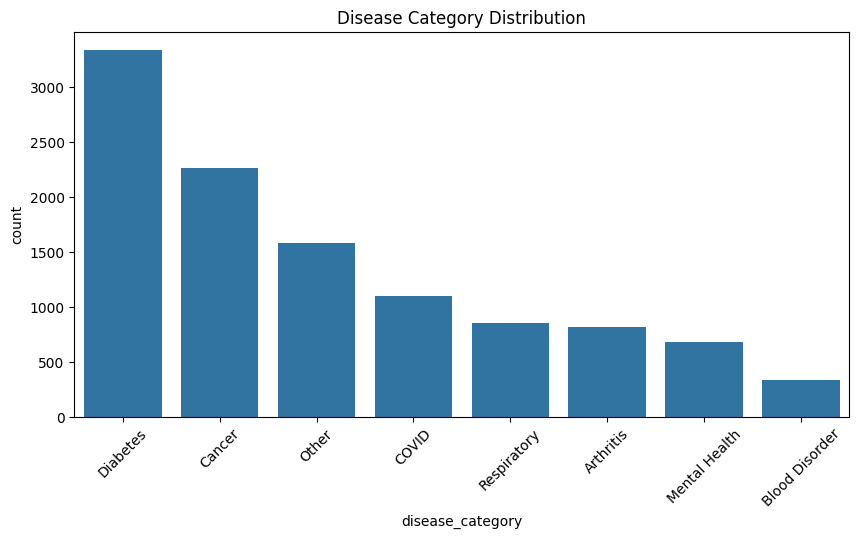

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='disease_category',
    data=df,
    order=df['disease_category'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Disease Category Distribution")
plt.show()

In [22]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [23]:
df["clean_summary"] = df["brief_summary"].apply(clean_text)

In [24]:
df[["brief_summary","clean_summary"]].head()

,brief_summary,clean_summary
0,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
3,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
22,This is an open-label study to assess the safe...,open label study assess safety tolerability ef...
27,"SMART is a Phase III, randomised, non-blinded ...",smart phase iii randomised non blinded screeni...
42,"Background:\n\nETBX-011, ETBX-061, and ETBX-05...",background etbx etbx etbx cancer vaccine goal ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["clean_summary"]
y = df["disease_category"]

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

(10971, 5000)


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['Arthritis' 'Blood Disorder' 'COVID' 'Cancer' 'Diabetes' 'Mental Health'
 'Other' 'Respiratory']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8776, 5000)
(2195, 5000)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.8419134396355353


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

     Arthritis       0.98      0.78      0.87       166
Blood Disorder       0.93      0.84      0.89        83
         COVID       0.81      0.85      0.83       224
        Cancer       0.93      0.93      0.93       451
      Diabetes       0.85      0.98      0.91       633
 Mental Health       0.86      0.71      0.77       136
         Other       0.56      0.52      0.54       314
   Respiratory       0.92      0.85      0.88       188

      accuracy                           0.84      2195
     macro avg       0.86      0.81      0.83      2195
  weighted avg       0.84      0.84      0.84      2195



In [30]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(
    "Naive Bayes Accuracy:",
    accuracy_score(y_test, y_pred_nb)
)

Naive Bayes Accuracy: 0.778132118451025


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.8437357630979498


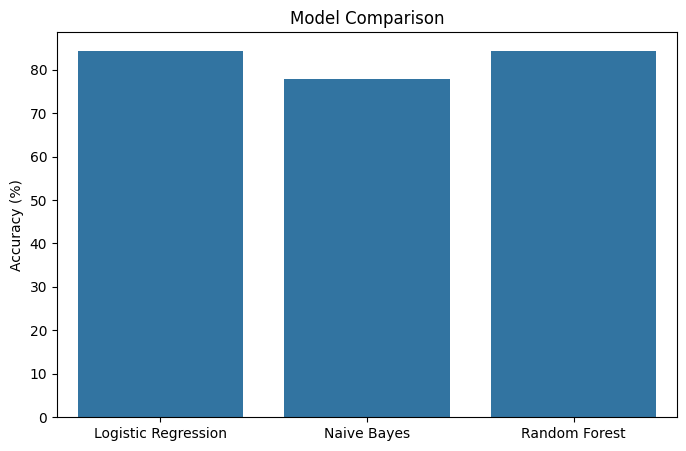

In [32]:
models = ["Logistic Regression", "Naive Bayes", "Random Forest"]

scores = [84.19, 77.81, 84.37]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")

plt.show()

# Model Saving
Saving the trained Random Forest model, TF-IDF vectorizer, and Label Encoder for future predictions and Streamlit deployment.

In [33]:
import pickle

pickle.dump(
    rf,
    open("disease_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("tfidf.pkl", "wb")
)

pickle.dump(
    le,
    open("label_encoder.pkl", "wb")
)

print("Files Saved Successfully")

Files Saved Successfully


# Disease Prediction Function
Creating a reusable function to predict disease categories from new clinical trial summaries.

In [37]:
def predict_disease(text):

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = rf.predict(vector)

    return le.inverse_transform(prediction)[0]

# Sample Prediction Test
Testing the trained model using a sample clinical trial summary to verify the end-to-end prediction pipeline.

In [38]:
sample_text = """
Patients with type 2 diabetes are being treated
with a new insulin therapy.
"""

print("Predicted Disease Category:", predict_disease(sample_text))

Predicted Disease Category: Diabetes
